## LightGBM

In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    %pip install -q -r requirements.txt

    import os
    from google.colab import userdata
    os.environ["DAGSHUB_TOKEN"]    = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]    = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_USERNAME"]  = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"]       = userdata.get("KAGGLE_KEY")

    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

### 1. Setup and Imports

In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
# Avoids BrokenPipeError from W&B's background service after a sleep/wake
# cycle or crashed kernel; runs wandb in-process instead.
os.environ.setdefault("WANDB_DISABLE_SERVICE", "true")

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import lightgbm as lgb

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking
from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.lightgbm_utils import (
    FEATURE_COLS,
    CATEGORICAL_COLS,
    build_series_lookup,
    attach_lag_features,
    prepare_model_frame,
)
from src.pipeline.lightgbm_pipeline import LightGBMForecastPipeline

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

print("Current MLflow URI:", mlflow.get_tracking_uri())

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE = "#7196C7"
GREEN = "#5E9D74"
RED = "#7E3838"
PURPLE = "#705588"

REGIME_COLORS = {
    "underfit": PURPLE,
    "balanced": BLUE,
    "overfit": RED,
}

STATUS_COLORS = {
    "good": GREEN,
    "underfit": PURPLE,
    "overfit": RED,
}

print("Setup complete.")

Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [2]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "LightGBM_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "horizon": 26,
    "random_seed": 42,
    "lag_weeks": 52,
    "roll_window": 26,
    "subsample_freq": 1,
    "n_jobs": -1,
}

MODEL_COL = "LightGBM"

CONFIG

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'horizon': 26,
 'random_seed': 42,
 'lag_weeks': 52,
 'roll_window': 26,
 'subsample_freq': 1,
 'n_jobs': -1}

### 3. Load Data

In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()

train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [4]:
train_prepared = apply_shared_features(train_df)

print(f"train_prepared: {train_prepared.shape}")
train_prepared.head()

train_prepared: (421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Model-Specific Feature Engineering

In [5]:
# Unlike ARIMA/DLinear/NBEATS (target-history-only, one model per series),
# LightGBM is a single global tabular model across all Store-Dept series, so it
# can directly consume the shared exogenous features (Temperature, Fuel_Price,
# CPI, Unemployment, MarkDowns, Type, Size, calendar features) plus Store/Dept
# as native categoricals.
#
# On top of that we add a small set of historical-sales features: a 52-week
# lag ("same week last year") and a trailing 26-week mean/std computed as of
# that lagged date. A lag of 52 weeks is leakage-safe for any row in this
# competition, because the forecast horizon is at most 39 weeks -- so for any
# date D we ever predict, D - 52 weeks is always at or before the training
# cutoff, never a future value. See src/lightgbm_utils.py.

lookup = build_series_lookup(train_prepared)

print(f"Built history lookup for {len(lookup)} Store-Dept series")

sample_id = next(iter(lookup))
display(lookup[sample_id].tail())

sample_features = attach_lag_features(train_prepared.head(2000), lookup)
print("\nColumns added:", ["lag_52", "roll_mean_26_lag52", "roll_std_26_lag52"])
sample_features[["Store", "Dept", "Date", "Weekly_Sales", "lag_52", "roll_mean_26_lag52", "roll_std_26_lag52"]].tail()

Built history lookup for 3331 Store-Dept series


,y,roll_mean_26,roll_std_26
Date,,,
2012-09-28,31477.50,32704.925000,21724.277557
2012-10-05,36323.95,29481.563462,12487.084348
2012-10-12,40626.47,27609.831154,3763.366562
2012-10-19,44224.36,28281.546538,4970.560951
2012-10-26,58409.83,29546.380385,7684.210335



Columns added: ['lag_52', 'roll_mean_26_lag52', 'roll_std_26_lag52']


,Store,Dept,Date,Weekly_Sales,lag_52,roll_mean_26_lag52,roll_std_26_lag52
1995,1,14,2012-09-14,11596.10,13166.76,12985.763846,1265.076059
1996,1,14,2012-09-21,12193.80,11558.22,12891.583846,1277.105815
1997,1,14,2012-09-28,12037.66,14027.83,12925.881154,1295.772585
1998,1,14,2012-10-05,14381.21,12766.52,12860.970769,1257.867808
1999,1,14,2012-10-12,11450.64,13440.89,12910.566538,1254.187354


### 6. Feature Selection

In [6]:
LIGHTGBM_FEATURE_DECISION = {
    "feature_set": "full_features_plus_safe_lag",
    "uses_exogenous_features": True,
    "used_model_columns": ", ".join(FEATURE_COLS),
    "reason": (
        "LightGBM is a single global tabular model, not a per-series statistical "
        "or history-only model, so it can exploit exogenous features (weather, "
        "economy, markdowns, store type/size, calendar) alongside Store/Dept "
        "categoricals and a leakage-safe 52-week sales lag."
    ),
}

LIGHTGBM_FEATURE_DECISION

{'feature_set': 'full_features_plus_safe_lag',
 'uses_exogenous_features': True,
 'used_model_columns': 'Store, Dept, IsHoliday, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, Size, Type_A, Type_B, Type_C, Year, Month, WeekOfYear, DaysSinceLastHoliday, DaysToNextHoliday, lag_52, roll_mean_26_lag52, roll_std_26_lag52',
 'reason': 'LightGBM is a single global tabular model, not a per-series statistical or history-only model, so it can exploit exogenous features (weather, economy, markdowns, store type/size, calendar) alongside Store/Dept categoricals and a leakage-safe 52-week sales lag.'}

### 7. Time-Series and Window Setup

In [7]:
train_part, valid_part = time_based_split(
    train_prepared,
    valid_weeks=CONFIG["horizon"],
)

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")
print(f"\nForecast horizon: {CONFIG['horizon']} weeks")

train_feat = attach_lag_features(train_part, lookup)
valid_feat = attach_lag_features(valid_part, lookup)

X_train = train_feat[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
X_valid = valid_feat[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
for col in CATEGORICAL_COLS:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

y_train = train_feat["Weekly_Sales"].astype(float)
y_valid = valid_feat["Weekly_Sales"].astype(float)

holiday_train = train_feat["IsHoliday"].fillna(0).astype(bool)
holiday_valid = valid_feat["IsHoliday"].fillna(0).astype(bool)

print(f"\nTrain rows: {len(X_train):,}  |  Valid rows: {len(X_valid):,}")
print(f"lag_52 missing in train: {X_train['lag_52'].isna().mean():.1%}")
print(f"lag_52 missing in valid: {X_valid['lag_52'].isna().mean():.1%}")


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return np.nan
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"


def make_lightgbm(config):
    return lgb.LGBMRegressor(
        num_leaves=config["num_leaves"],
        max_depth=config["max_depth"],
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        min_child_samples=config["min_child_samples"],
        subsample=config["subsample"],
        subsample_freq=CONFIG["subsample_freq"],
        colsample_bytree=config["colsample_bytree"],
        reg_alpha=config["reg_alpha"],
        reg_lambda=config["reg_lambda"],
        random_state=CONFIG["random_seed"],
        n_jobs=CONFIG["n_jobs"],
        verbosity=-1,
    )


def evaluate_lightgbm_config(config):
    model = make_lightgbm(config)
    model.fit(X_train, y_train, categorical_feature=CATEGORICAL_COLS)

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    train_eval = pd.DataFrame({"y": y_train.to_numpy(), MODEL_COL: train_pred, "IsHoliday": holiday_train.to_numpy()})
    valid_eval = pd.DataFrame({"y": y_valid.to_numpy(), MODEL_COL: valid_pred, "IsHoliday": holiday_valid.to_numpy()})

    train_wmae = wmae_from_df(train_eval, "y", MODEL_COL, "IsHoliday")
    val_wmae = wmae_from_df(valid_eval, "y", MODEL_COL, "IsHoliday")

    cv_df = valid_feat[["Store", "Dept", "Date", "IsHoliday"]].copy()
    cv_df["y"] = y_valid.to_numpy()
    cv_df[MODEL_COL] = valid_pred

    return model, cv_df, float(train_wmae), float(val_wmae)

Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Forecast horizon: 39 weeks

Train rows: 305,982  |  Valid rows: 115,588
lag_52 missing in train: 51.3%
lag_52 missing in valid: 2.7%


### 8. Forward and Backward Check

In [8]:
sanity_config = {
    "label": "sanity_lightgbm",
    "regime": "sanity",
    "num_leaves": 15,
    "max_depth": 4,
    "n_estimators": 5,
    "learning_rate": 0.1,
    "min_child_samples": 20,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
}

sanity_model, sanity_cv_df, sanity_train_wmae, sanity_val_wmae = evaluate_lightgbm_config(sanity_config)

assert len(sanity_cv_df) == len(X_valid)
assert np.isfinite(sanity_cv_df[MODEL_COL]).all()

print("LightGBM sanity check passed")
print(f"Sanity train WMAE: {sanity_train_wmae:,.2f}")
print(f"Sanity val WMAE:   {sanity_val_wmae:,.2f}")
sanity_cv_df.head()

LightGBM sanity check passed
Sanity train WMAE: 10,562.97
Sanity val WMAE:   9,890.27


,Store,Dept,Date,IsHoliday,y,LightGBM
104,1,1,2012-02-03,0,23510.49,21184.009329
105,1,1,2012-02-10,1,36988.49,22864.270113
106,1,1,2012-02-17,0,54060.10,28608.273402
107,1,1,2012-02-24,0,20124.22,20562.606102
108,1,1,2012-03-02,0,20113.03,20562.606102


### 9. Baseline Run

In [9]:
baseline_config = {
    "label": "baseline_lightgbm",
    "regime": "baseline",
    "num_leaves": 31,
    "max_depth": -1,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
}

with mlflow.start_run(run_name="LightGBM_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="LightGBM_Baseline",
        group="LightGBM",
        job_type="baseline",
        tags=["LightGBM", "baseline", "full_features_plus_safe_lag"],
        config={**CONFIG, **baseline_config, **LIGHTGBM_FEATURE_DECISION},
        reinit=True,
    )

    try:
        baseline_model, baseline_cv_df, baseline_train_wmae, baseline_val_wmae = evaluate_lightgbm_config(baseline_config)

        gap_pct = fit_gap_pct(baseline_train_wmae, baseline_val_wmae)
        fit_status = classify_fit_status(baseline_train_wmae, baseline_val_wmae)

        print(f"Baseline train WMAE:      {baseline_train_wmae:,.2f}")
        print(f"Baseline validation WMAE: {baseline_val_wmae:,.2f}")
        print(f"Baseline gap:             {gap_pct:,.2f}% ({fit_status})")

        mlflow.log_params({**CONFIG, **LIGHTGBM_FEATURE_DECISION})
        mlflow.log_params({k: v for k, v in baseline_config.items()})
        mlflow.log_metric("train_wmae", baseline_train_wmae)
        mlflow.log_metric("val_wmae", baseline_val_wmae)
        mlflow.log_metric("gap_pct", gap_pct)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_param("gradient_logging_applicable", False)
        mlflow.log_param(
            "gradient_logging_reason",
            "LightGBM is a gradient-boosted tree ensemble, not a neural backpropagation model.",
        )

        wandb.log({
            "train_wmae": baseline_train_wmae,
            "val_wmae": baseline_val_wmae,
            "gap_pct": gap_pct,
            "fit_status": fit_status,
        })

        os.makedirs("artifacts", exist_ok=True)
        baseline_dir = Path("artifacts") / "lightgbm_baseline"
        baseline_dir.mkdir(parents=True, exist_ok=True)
        baseline_model_path = baseline_dir / "lightgbm_model.joblib"

        joblib.dump(
            {
                "model": baseline_model,
                "lookup": lookup,
                "feature_cols": FEATURE_COLS,
                "categorical_cols": CATEGORICAL_COLS,
                "config": baseline_config,
            },
            baseline_model_path,
        )

        mlflow.log_artifacts(str(baseline_dir), artifact_path="lightgbm_model")

        baseline_run_id = run.info.run_id

    finally:
        wandb.finish()

wandb: WARNING Disabling the wandb service is deprecated as of version 0.18.0 and will be removed in future versions. 
wandb: Currently logged in as: lchit22 (dkhak22-free-university-of-tbilisi-). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Baseline train WMAE:      2,326.38
Baseline validation WMAE: 1,864.71
Baseline gap:             -19.85% (underfit)


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 19:47:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_Baseline at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/91e7a2ddc2a441b1a7e2b26eb1c7984d.
2026/07/12 19:47:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.


### 10. Hyperparameters

In [10]:
param_grid = [
    {"label": "underfit_1", "regime": "underfit", "num_leaves": 2,   "max_depth": 1,  "n_estimators": 10, "learning_rate": 0.01,  "min_child_samples": 2000, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "underfit_2", "regime": "underfit", "num_leaves": 2,   "max_depth": 1,  "n_estimators": 20, "learning_rate": 0.01,  "min_child_samples": 3000, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "underfit_3", "regime": "underfit", "num_leaves": 4,   "max_depth": 2,  "n_estimators": 15, "learning_rate": 0.005, "min_child_samples": 2000, "subsample": 1.0, "colsample_bytree": 0.5, "reg_alpha": 1.0, "reg_lambda": 1.0},
    {"label": "underfit_4", "regime": "underfit", "num_leaves": 4,   "max_depth": 2,  "n_estimators": 30, "learning_rate": 0.01,  "min_child_samples": 4000, "subsample": 1.0, "colsample_bytree": 0.3, "reg_alpha": 2.0, "reg_lambda": 2.0},
    {"label": "underfit_5", "regime": "underfit", "num_leaves": 8,   "max_depth": 3,  "n_estimators": 15, "learning_rate": 0.005, "min_child_samples": 5000, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "underfit_6", "regime": "underfit", "num_leaves": 2,   "max_depth": 1,  "n_estimators": 50, "learning_rate": 0.001, "min_child_samples": 1000, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},

    {"label": "balanced_1",  "regime": "balanced", "num_leaves": 31,  "max_depth": -1, "n_estimators": 200, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "balanced_2",  "regime": "balanced", "num_leaves": 31,  "max_depth": -1, "n_estimators": 300, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "balanced_3",  "regime": "balanced", "num_leaves": 15,  "max_depth": 6,  "n_estimators": 300, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1},
    {"label": "balanced_4",  "regime": "balanced", "num_leaves": 63,  "max_depth": -1, "n_estimators": 200, "learning_rate": 0.05, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.7, "reg_alpha": 0.1, "reg_lambda": 0.1},
    {"label": "balanced_5",  "regime": "balanced", "num_leaves": 63,  "max_depth": -1, "n_estimators": 350, "learning_rate": 0.03, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5},
    {"label": "balanced_6",  "regime": "balanced", "num_leaves": 31,  "max_depth": 8,  "n_estimators": 300, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.7, "colsample_bytree": 0.7, "reg_alpha": 0.5, "reg_lambda": 0.5},
    {"label": "balanced_7",  "regime": "balanced", "num_leaves": 31,  "max_depth": 8,  "n_estimators": 400, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.1},
    {"label": "balanced_8",  "regime": "balanced", "num_leaves": 63,  "max_depth": 10, "n_estimators": 300, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.0},
    {"label": "balanced_9",  "regime": "balanced", "num_leaves": 127, "max_depth": -1, "n_estimators": 200, "learning_rate": 0.05, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.7, "reg_alpha": 1.0, "reg_lambda": 1.0},
    {"label": "balanced_10", "regime": "balanced", "num_leaves": 127, "max_depth": -1, "n_estimators": 300, "learning_rate": 0.03, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.7, "reg_alpha": 0.5, "reg_lambda": 0.5},
    {"label": "balanced_11", "regime": "balanced", "num_leaves": 63,  "max_depth": 8,  "n_estimators": 500, "learning_rate": 0.03, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.7, "reg_alpha": 0.1, "reg_lambda": 0.1},
    {"label": "balanced_12", "regime": "balanced", "num_leaves": 31,  "max_depth": -1, "n_estimators": 500, "learning_rate": 0.03, "min_child_samples": 20, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "balanced_13", "regime": "balanced", "num_leaves": 15,  "max_depth": -1, "n_estimators": 500, "learning_rate": 0.05, "min_child_samples": 10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1},
    {"label": "balanced_14", "regime": "balanced", "num_leaves": 127, "max_depth": 8,  "n_estimators": 250, "learning_rate": 0.08, "min_child_samples": 30, "subsample": 0.7, "colsample_bytree": 0.6, "reg_alpha": 1.0, "reg_lambda": 1.0},
    {"label": "balanced_15", "regime": "balanced", "num_leaves": 63,  "max_depth": -1, "n_estimators": 300, "learning_rate": 0.08, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 0.5},
    {"label": "balanced_16", "regime": "balanced", "num_leaves": 31,  "max_depth": 6,  "n_estimators": 250, "learning_rate": 0.1,  "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1},
    {"label": "balanced_17", "regime": "balanced", "num_leaves": 63,  "max_depth": 10, "n_estimators": 350, "learning_rate": 0.05, "min_child_samples": 10, "subsample": 0.9, "colsample_bytree": 0.9, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "balanced_18", "regime": "balanced", "num_leaves": 95,  "max_depth": -1, "n_estimators": 300, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5},

    {"label": "overfit_1", "regime": "overfit", "num_leaves": 511,  "max_depth": -1, "n_estimators": 2000, "learning_rate": 0.1,  "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "overfit_2", "regime": "overfit", "num_leaves": 1023, "max_depth": -1, "n_estimators": 3000, "learning_rate": 0.1,  "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "overfit_3", "regime": "overfit", "num_leaves": 2047, "max_depth": -1, "n_estimators": 3000, "learning_rate": 0.15, "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "overfit_4", "regime": "overfit", "num_leaves": 255,  "max_depth": -1, "n_estimators": 3000, "learning_rate": 0.2,  "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "overfit_5", "regime": "overfit", "num_leaves": 1023, "max_depth": 20, "n_estimators": 3000, "learning_rate": 0.15, "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"label": "overfit_6", "regime": "overfit", "num_leaves": 4095, "max_depth": -1, "n_estimators": 3000, "learning_rate": 0.15, "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
]

print(f"Total LightGBM configs: {len(param_grid)}")

Total LightGBM configs: 30


### 11. LightGBM Experiments

In [12]:
results = []
cv_by_label = {}
model_by_label = {}

best_val_wmae = float("inf")
best_run_id = None
best_label = None
best_lightgbm_model_path = None

with mlflow.start_run(run_name="LightGBM_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("feature_set", LIGHTGBM_FEATURE_DECISION["feature_set"])
    mlflow.log_param("gradient_logging_applicable", False)

    for config in param_grid:
        label = config["label"]
        regime = config["regime"]

        with mlflow.start_run(run_name=f"LightGBM_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"LightGBM_{label}",
                group="LightGBM",
                job_type="hyperparameter_sweep",
                tags=["LightGBM", regime, "full_features_plus_safe_lag"],
                config={**CONFIG, **config, **LIGHTGBM_FEATURE_DECISION},
                reinit=True,
            )

            try:
                model, cv_df, train_wmae, val_wmae = evaluate_lightgbm_config(config)
                cv_by_label[label] = cv_df.copy()

                gap_pct = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({**config, "feature_set": LIGHTGBM_FEATURE_DECISION["feature_set"]})
                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)

                wandb.log({
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                })

                results.append({
                    **config,
                    "feature_set": LIGHTGBM_FEATURE_DECISION["feature_set"],
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "status": fit_status,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label
                    model_by_label[label] = model

                    os.makedirs("artifacts", exist_ok=True)
                    checkpoint_dir = Path("artifacts") / f"lightgbm_{label}"
                    checkpoint_dir.mkdir(parents=True, exist_ok=True)
                    best_lightgbm_model_path = checkpoint_dir / "lightgbm_model.joblib"

                    joblib.dump(
                        {
                            "model": model,
                            "lookup": lookup,
                            "feature_cols": FEATURE_COLS,
                            "categorical_cols": CATEGORICAL_COLS,
                            "config": config,
                        },
                        best_lightgbm_model_path,
                    )

                    mlflow.log_artifacts(str(checkpoint_dir), artifact_path="lightgbm_model")

                    print(
                        f"New best: {best_label} | "
                        f"train WMAE = {train_wmae:,.2f} | "
                        f"val WMAE = {best_val_wmae:,.2f} | "
                        f"gap = {gap_pct:,.2f}% ({fit_status})"
                    )

            finally:
                wandb.finish()

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/12 20:24:09 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:24:09 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forec

KeyboardInterrupt: 

### 12. Results

In [13]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label", "regime", "status",
    "num_leaves", "max_depth", "n_estimators", "learning_rate",
    "min_child_samples", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
    "train_wmae", "val_wmae", "gap_pct",
]

display(results_df[display_cols])

os.makedirs("reports", exist_ok=True)
results_path = "reports/lightgbm_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)

,label,regime,status,num_leaves,max_depth,n_estimators,learning_rate,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,train_wmae,val_wmae,gap_pct
0,underfit_1,underfit,good,2,1,10,0.01,2000,1.0,1.0,0.0,0.0,14815.581189,14649.42074,-1.121525


2026/07/12 20:24:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:24:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.


### 13. Plots

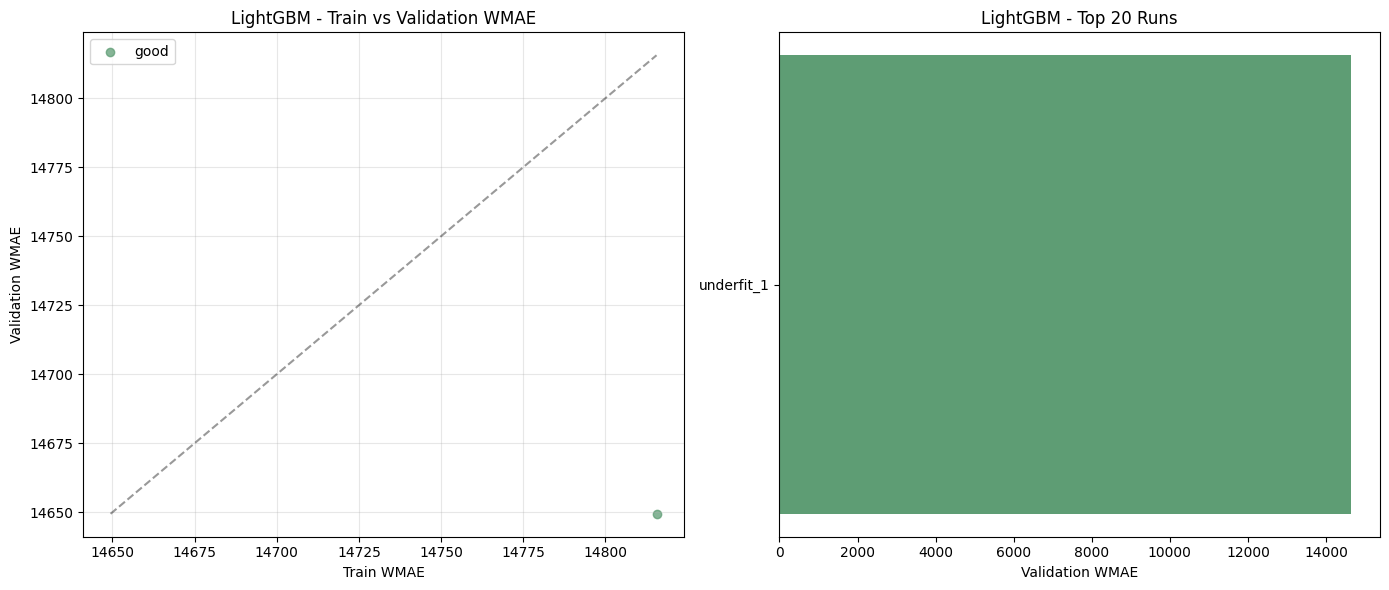

2026/07/12 20:24:40 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:24:40 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't im

In [14]:
os.makedirs("Plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for status, status_df in results_df.groupby("status"):
    axes[0].scatter(
        status_df["train_wmae"],
        status_df["val_wmae"],
        c=STATUS_COLORS.get(status, BLUE),
        alpha=0.75,
        label=status,
    )

min_wmae = float(results_df[["train_wmae", "val_wmae"]].min().min())
max_wmae = float(results_df[["train_wmae", "val_wmae"]].max().max())
axes[0].plot([min_wmae, max_wmae], [min_wmae, max_wmae], color="black", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Train WMAE")
axes[0].set_ylabel("Validation WMAE")
axes[0].set_title("LightGBM - Train vs Validation WMAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top20 = results_df.head(20)
axes[1].barh(
    top20["label"],
    top20["val_wmae"],
    color=top20["status"].map(lambda s: STATUS_COLORS.get(s, BLUE)),
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Validation WMAE")
axes[1].set_title("LightGBM - Top 20 Runs")

plt.tight_layout()

plot_path = "Plots/lightgbm_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="LightGBM_Analysis",
    group="LightGBM",
    job_type="analysis",
    tags=["LightGBM", "analysis", "train_validation_gap"],
    reinit=True,
)

wandb.log({
    "lightgbm_wmae_comparison": wandb.Image(plot_path),
    "best_val_wmae": best_val_wmae,
})

wandb.finish()

### 14. Feature Importance

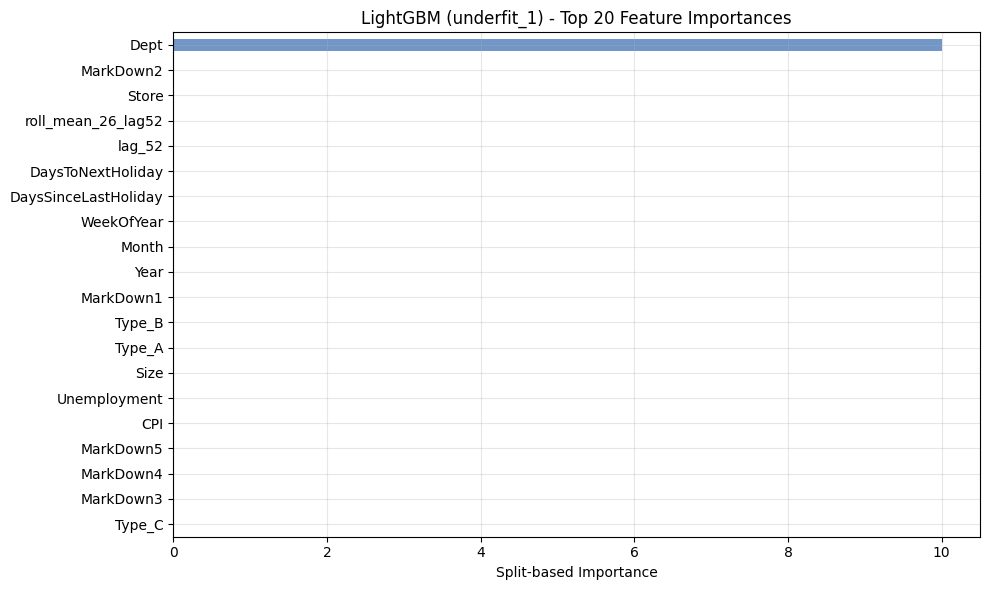

2026/07/12 20:24:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:24:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't im

In [15]:
best_lightgbm_payload = joblib.load(best_lightgbm_model_path)
best_model_obj = best_lightgbm_payload["model"]

importance = pd.Series(
    best_model_obj.feature_importances_,
    index=best_model_obj.feature_name_,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh", ax=ax, color=BLUE)
ax.set_xlabel("Split-based Importance")
ax.set_title(f"LightGBM ({best_label}) - Top 20 Feature Importances")
ax.grid(True, alpha=0.3)

plt.tight_layout()
importance_plot_path = "Plots/lightgbm_feature_importance.png"
plt.savefig(importance_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(importance_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="LightGBM_FeatureImportance",
    group="LightGBM",
    job_type="analysis",
    tags=["LightGBM", "feature_importance"],
    reinit=True,
)

wandb.log({"lightgbm_feature_importance": wandb.Image(importance_plot_path)})

wandb.finish()

### 15. Error Analysis

In [16]:
best_cv_df = cv_by_label[best_label].copy()
best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df[MODEL_COL]).abs()

display(best_cv_df.head())

worst_store_dept = (
    best_cv_df
    .groupby(["Store", "Dept"])["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(worst_store_dept)

holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae", float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))

,Store,Dept,Date,IsHoliday,y,LightGBM,abs_error
104,1,1,2012-02-03,0,23510.49,15459.227736,8051.262264
105,1,1,2012-02-10,1,36988.49,15459.227736,21529.262264
106,1,1,2012-02-17,0,54060.10,15459.227736,38600.872264
107,1,1,2012-02-24,0,20124.22,15459.227736,4664.992264
108,1,1,2012-03-02,0,20113.03,15459.227736,4653.802264


Store  Dept
13     92      155244.154426
20     92      153420.712887
4      92      150893.534939
2      92      150725.542118
14     92      149226.206990
4      95      142136.182887
20     95      134901.241349
2      95      129394.425964
13     95      127829.253144
1      92      122766.355451
27     92      122706.035195
31     92      111211.191605
14     95      108649.921349
1      95      108119.782631
24     92      106574.165964
Name: abs_error, dtype: float64

IsHoliday
0    14524.192408
1    15109.539894
Name: abs_error, dtype: float64

2026/07/12 20:25:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:25:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.


### 16. Error Plots

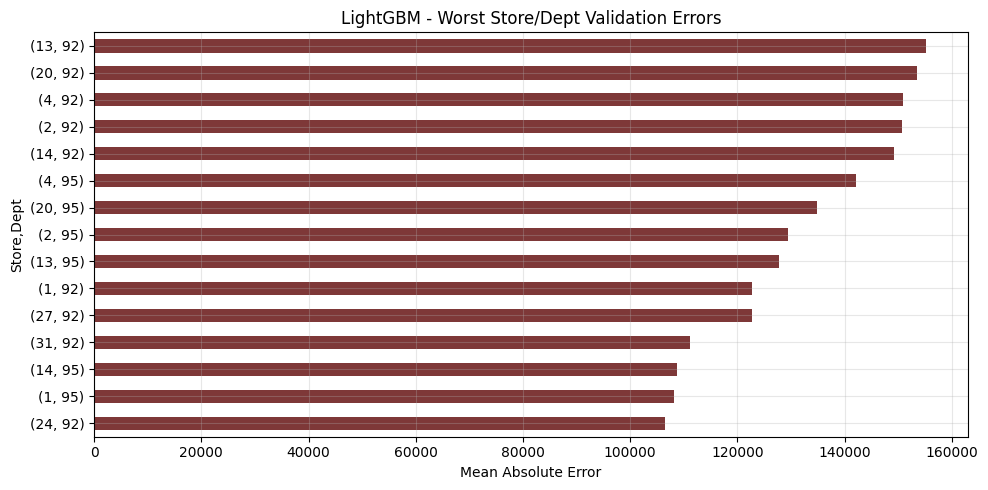

2026/07/12 20:25:20 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM_underfit_1 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5/runs/98d5141c4de64a42a08cde240c44258c.
2026/07/12 20:25:20 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/5.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't im

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

worst_store_dept.sort_values().plot(
    kind="barh",
    ax=ax,
    color=RED,
)

ax.set_xlabel("Mean Absolute Error")
ax.set_title("LightGBM - Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)

plt.tight_layout()
error_plot_path = "Plots/lightgbm_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="LightGBM_Error_Analysis",
    group="LightGBM",
    job_type="analysis",
    tags=["LightGBM", "error_analysis"],
    reinit=True,
)

wandb.log({
    "lightgbm_worst_store_dept": wandb.Image(error_plot_path),
    "holiday_week_mae": float(holiday_error.get(True, np.nan)),
    "nonholiday_week_mae": float(holiday_error.get(False, np.nan)),
})

wandb.finish()

### 17. Best Model

In [21]:
print("Best label:", best_label)
print("Best run id:", best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]
best_config = next(config for config in param_grid if config["label"] == best_label)

print("Best config:")
display(best_config)

fallback_by_id = (
    train_prepared.assign(
        unique_id=train_prepared["Store"].astype(str) + "_" + train_prepared["Dept"].astype(str)
    )
    .sort_values("Date")
    .groupby("unique_id")["Weekly_Sales"]
    .last()
    .astype(float)
    .to_dict()
)
global_fallback = float(train_prepared["Weekly_Sales"].median())

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")

full_feat = attach_lag_features(train_prepared, lookup)
X_full = full_feat[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
for col in CATEGORICAL_COLS:
    X_full[col] = X_full[col].astype("category")
y_full = full_feat["Weekly_Sales"].astype(float)

final_model = make_lightgbm(best_config)
final_model.fit(X_full, y_full, categorical_feature=CATEGORICAL_COLS)

print("Final LightGBM model fitted on the full training history.")

os.makedirs("artifacts", exist_ok=True)
final_model_dir = Path("artifacts") / f"lightgbm_final_{best_label}"
final_model_dir.mkdir(parents=True, exist_ok=True)
final_model_path = final_model_dir / "lightgbm_model.joblib"

joblib.dump(
    {
        "model": final_model,
        "lookup": lookup,
        "feature_cols": FEATURE_COLS,
        "categorical_cols": CATEGORICAL_COLS,
        "best_config": best_config,
        "fallback_by_id": fallback_by_id,
        "global_fallback": global_fallback,
    },
    final_model_path,
)

print("Final LightGBM model artifact saved to:", final_model_path)

pipeline_model = LightGBMForecastPipeline(
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)


class _SignatureContext:
    artifacts = {"lightgbm_model_path": str(final_model_path)}


_temp = LightGBMForecastPipeline(
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)
_temp.load_context(_SignatureContext())

sample_output = _temp.predict(_SignatureContext(), test_df)
signature = infer_signature(test_df, sample_output)

display(sample_output.head())

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("registered_model_name", "LightGBM_WalmartForecast")
    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_param("best_label", best_label)
    mlflow.log_params({f"best_{k}": v for k, v in best_config.items() if k not in ("label", "regime")})
    mlflow.log_param("best_regime", best_config["regime"])
    mlflow.log_param("fallback_method", "last_observed_sales_by_store_dept")
    mlflow.log_metric("global_fallback_weekly_sales", global_fallback)
    mlflow.log_param("final_gradient_logging_applicable", False)

    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        artifacts={"lightgbm_model_path": str(final_model_path)},
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="LightGBM_WalmartForecast",
    )

model_uri = logged_model_info.model_uri
print("Logged model URI:", model_uri)

Best label: underfit_1
Best run id: 98d5141c4de64a42a08cde240c44258c
Best validation WMAE: 14649.42073986588
Best config:


{'label': 'underfit_1',
 'regime': 'underfit',
 'num_leaves': 2,
 'max_depth': 1,
 'n_estimators': 10,
 'learning_rate': 0.01,
 'min_child_samples': 2000,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0}

Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03
Final LightGBM model fitted on the full training history.
Final LightGBM model artifact saved to: artifacts/lightgbm_final_underfit_1/lightgbm_model.joblib


/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


,Id,Weekly_Sales
0,1_1_2012-11-02,17554.306273
1,1_1_2012-11-09,15510.464862
2,1_1_2012-11-16,15510.464862
3,1_1_2012-11-23,15510.464862
4,1_1_2012-11-30,15510.464862


Registered model 'LightGBM_WalmartForecast' already exists. Creating a new version of this model...
2026/07/12 20:34:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LightGBM_WalmartForecast, version 2
Created version '2' of model 'LightGBM_WalmartForecast'.
2026/07/12 20:34:51 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "Store",
      "Dept",
      "Date",
      "IsHoliday",
      "Temperature",
      "Fuel_Price",
      "MarkDown1",
      "MarkDown2",
      "MarkDown3",
      "MarkDown4",
      "MarkDown5",
      "CPI",
      "Unemployment",
      "Type",
      "Size"
    ],
    "data": [
      [
        1,
        1,
        "2012-11-02T00:00:00",
        false,
        55.32,
        3.386,
        6766.44,
        5147.7,
        50.82,
        3639.9,
        2737.42,
        223.4627793,
        6.573,
        "A",
        15131

Logged model URI: runs:/98d5141c4de64a42a08cde240c44258c/pipeline


### 18. Test Loading

In [23]:
# This kernel already has `src.*` modules imported from cell 3 (before the
# transforms.py fix). mlflow.pyfunc.load_model reconstructs the pipeline by
# module name (e.g. "src.transforms"), and Python's import system returns
# whatever is already in sys.modules instead of re-importing from the fresh
# code_paths bundle -- so without this, the loaded model silently runs the
# stale pre-fix code even though the bundled artifact on disk is correct.
import sys
for _mod in list(sys.modules):
    if _mod == "src" or _mod.startswith("src."):
        del sys.modules[_mod]

loaded_model = mlflow.pyfunc.load_model(model_uri)
loaded_preds = loaded_model.predict(test_df.head(200))

display(loaded_preds.head())
print("Loaded prediction shape:", loaded_preds.shape)
assert set(loaded_preds.columns) == {"Id", "Weekly_Sales"}
assert loaded_preds["Weekly_Sales"].notna().all()

,Id,Weekly_Sales
0,1_1_2012-11-02,17554.306273
1,1_1_2012-11-09,15510.464862
2,1_1_2012-11-16,15510.464862
3,1_1_2012-11-23,15510.464862
4,1_1_2012-11-30,15510.464862


Loaded prediction shape: (200, 2)
